In [4]:
import pandas as pd
df_pairs = pd.read_csv('pairs.csv')      
df_terms = pd.read_csv('terms.csv')     
df_terms['term'] = df_terms['term'].str.strip().str.lower()
df_merged = df_pairs.merge(df_terms.rename(columns={'term': 'term1', 'field': 'field1'}), on='term1', how='left')
df_merged = df_merged.merge(df_terms.rename(columns={'term': 'term2', 'field': 'field2'}), on='term2', how='left')
df_merged[['field1', 'field2']] = df_merged[['field1', 'field2']].apply(lambda row: sorted(row), axis=1, result_type='expand')
def keep_bottom_10_percent(group):
    n = max(1, int(len(group) * 0.10)) 
    return group.nsmallest(n, 'similarity')
filtered_df = df_merged.groupby(['field1', 'field2'], group_keys=False).apply(keep_bottom_10_percent).reset_index(drop=True)
filtered_df = df_merged.nsmallest(1000, 'similarity').reset_index(drop=True)
filtered_df.to_csv('pairs.csv',index=False)

/tmp/ipykernel_3599464/394473367.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  filtered_df = df_merged.groupby(['field1', 'field2'], group_keys=False).apply(keep_bottom_10_percent).reset_index(drop=True)


In [ ]:
import pandas as pd
from openai import OpenAI
df = pd.read_csv('pairs.csv')
df=df.head(10)
# 2. Construct prompt for each row
def make_prompt(row):
    return (
        f"Two researchers, one is a specialist in {row['term1']} from the field of {row['field1']}, "
        f"and the other is an expert in {row['term2']} from the field of {row['field2']}. "
        "Write a brief research direction (a few sentences) that pictures how their expertise can be combined to create a successful interdisciplinary collaboration. "
        "Be brief."
        "Break down the task from concept to concept"
    )

df['prompt'] = df.apply(make_prompt, axis=1)
# 3. Set up OpenRouter API client
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="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",
)

def get_research_plan(prompt):
    try:
        response = client.chat.completions.create(
            messages=[{"role": "user", "content": prompt}],
            model="qwen/qwen-2.5-7b-instruct"
        )
        output_text = response.choices[0].message.content.strip()
        return output_text
    except Exception as e:
        print(f"Error: {e}")
        return f"ERROR: {str(e)}"

# 5. Generate research plan for each row
plans = []
for idx, row in df.iterrows():
    plan = get_research_plan(row['prompt'])
    plans.append(plan)
df['research_plan'] = plans
df

,term1,term2,similarity,field1,field2,prompt,research_plan
0,metagenomic sequencing,power dynamics,-0.146857,"a researcher in biology, chemistry, and medica...",a researcher in social sciences,"Two researchers, one is a specialist in metage...",**Concept 1: Metagenomic Sequencing Expertise*...
1,behavioral economics,proteomic mapping,-0.144754,"a researcher in biology, chemistry, and medica...",a researcher in social sciences,"Two researchers, one is a specialist in behavi...",### Research Direction\n\n**Concept 1: Behavio...
2,metagenomic sequencing,schrödinger equation,-0.138577,"a researcher in biology, chemistry, and medica...",a researcher in physics,"Two researchers, one is a specialist in metage...",### Research Direction\n\n**Concept 1: Metagen...
3,casimir effect,naive bayes,-0.133640,"a researcher in computational, mathematical, a...",a researcher in physics,"Two researchers, one is a specialist in casimi...",### Research Direction:\n\n**Concept 1: Utiliz...
4,chemogenetic activation,lattice gauge,-0.131522,"a researcher in biology, chemistry, and medica...",a researcher in physics,"Two researchers, one is a specialist in chemog...",### Concept Breakdown\n\n1. **Chemogenetic Act...
5,neuroimaging biomarker,power dynamics,-0.130910,"a researcher in biology, chemistry, and medica...",a researcher in social sciences,"Two researchers, one is a specialist in neuroi...",### Concept 1: Neuroimaging Biomarkers\n**Expe...
6,metagenomic sequencing,quantum tunneling,-0.127989,"a researcher in biology, chemistry, and medica...",a researcher in physics,"Two researchers, one is a specialist in metage...",### Concept Breakdown\n\n1. **Metagenomic Sequ...
7,spin precession,tissue engineering,-0.125937,"a researcher in biology, chemistry, and medica...",a researcher in physics,"Two researchers, one is a specialist in spin p...",### Concept Breakdown:\n\n1. **Spin Precession...
8,landau damping,metagenomic sequencing,-0.124323,"a researcher in biology, chemistry, and medica...",a researcher in physics,"Two researchers, one is a specialist in landau...",### Concept Breakdown\n\n1. **Landau Damping S...
9,metagenomic sequencing,photoelectric effect,-0.121980,"a researcher in biology, chemistry, and medica...",a researcher in physics,"Two researchers, one is a specialist in metage...",### Concept Breakdown\n\n1. **Metagenomic Sequ...


In [28]:
df['research_plan'][0]

'**Concept 1: Metagenomic Sequencing Expertise**\nThe metagenomics expert can sequence microorganisms from various environmental and clinical samples, generating vast amounts of genetic data that can reveal the microbial composition of different ecosystems or human microbiomes.\n\n**Concept 2: Power Dynamics Expertise**\nThe power dynamics expert can analyze how different social, cultural, and economic factors influence access to health resources and how power structures affect the distribution and interpretation of genetic data.\n\n**Concept 3: Combining Expertise**\nBy combining their expertise, the team can research how social and institutional power dynamics impact the collection, interpretation, and application of metagenomic data. For instance, they can investigate how disparities in healthcare access and funding shape the availability and quality of microbial samples, and how these factors influence public health outcomes related to microbial ecology.\n\n**Research Direction:**\

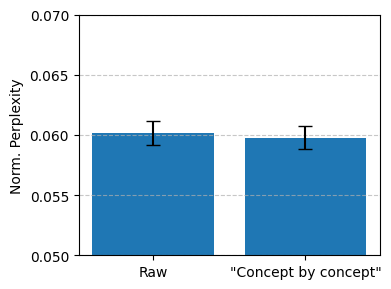

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('/home/honglinbao/chain_of_hints/ppl.csv')
df['raw_ppl_norm'] = df['raw_ppl'] / df['raw_token_count']
df['cot_ppl_norm'] = df['cot_ppl'] / df['cot_token_count']
def trim_outliers(series):
    lower = series.quantile(0.01)
    upper = series.quantile(0.99)
    return series[(series >= lower) & (series <= upper)]

raw_trimmed = trim_outliers(df['raw_ppl_norm'])
coc_trimmed = trim_outliers(df['cot_ppl_norm'])
valid_idx = raw_trimmed.index.intersection(coc_trimmed.index)
raw_trimmed = raw_trimmed.loc[valid_idx]
coc_trimmed = coc_trimmed.loc[valid_idx]
means = [raw_trimmed.mean(), coc_trimmed.mean()]
stds = [raw_trimmed.std(), coc_trimmed.std()]
n = len(valid_idx)
cis = 1.96 * np.array(stds) / np.sqrt(n)
plt.figure(figsize=(4, 3))
plt.ylim(0.05,0.07)
bars = plt.bar(['Raw', '"Concept by concept"'], means, yerr=cis, capsize=5)
plt.ylabel("Norm. Perplexity")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
df

,term1,term2,similarity,field1,field2,research_plan_raw,research_plan_coc,raw_ppl,coc_ppl,raw_token_count,coc_token_count,raw_ppl_norm,coc_ppl_norm
0,metagenomic sequencing,power dynamics,-0.146857,"a researcher in biology, chemistry, and medica...",a researcher in social sciences,"I think possibility 1, ""The impact of heat str...",By combining the strengths of both researchers...,9.269629,54.745991,63,11,0.147137,4.976908
1,behavioral economics,proteomic mapping,-0.144754,"a researcher in biology, chemistry, and medica...",a researcher in social sciences,To ensure that their research is conducted in ...,To combine the expertise of the two researcher...,2.526837,3.035146,123,311,0.020543,0.009759
2,metagenomic sequencing,schrödinger equation,-0.138577,"a researcher in biology, chemistry, and medica...",a researcher in physics,"The researcher in biology, chemistry, and medi...",To combine the expertise of the two researcher...,5.563776,2.742328,123,332,0.045234,0.008260
3,casimir effect,naive bayes,-0.133640,"a researcher in computational, mathematical, a...",a researcher in physics,A potential research direction could be the us...,To suggest a concise interdisciplinary researc...,8.424463,1.813129,54,1024,0.156009,0.001771
4,chemogenetic activation,lattice gauge,-0.131522,"a researcher in biology, chemistry, and medica...",a researcher in physics,Excellent identification of the key challenges...,To combine the expertise of the biology/chemis...,4.249825,3.023016,330,270,0.012878,0.011196
...,...,...,...,...,...,...,...,...,...,...,...,...,...
991,optical lattice,role conflict,-0.038974,a researcher in physics,a researcher in social sciences,"I would prioritize suggestions 1, 2, 3, 5, and...",To combine the expertise of the two researcher...,3.134206,1.856649,190,1025,0.016496,0.001811
992,gene silencing,power dynamics,-0.038950,"a researcher in biology, chemistry, and medica...",a researcher in social sciences,"A potential research direction could be ""Explo...","To combine the researchers' expertise, let's b...",7.440547,2.670979,90,313,0.082673,0.008533
993,bandit algorithms,surface plasmon,-0.038936,"a researcher in computational, mathematical, a...",a researcher in physics,A potential research direction could be the de...,To break down the challenges associated with t...,3.972835,2.540003,156,196,0.025467,0.012959
994,cognitive dissonance,trie structures,-0.038931,"a researcher in computational, mathematical, a...",a researcher in social sciences,"A potential research direction could be ""Cogni...",To combine the expertise of the two researcher...,5.283309,1.731900,139,1025,0.038009,0.001690


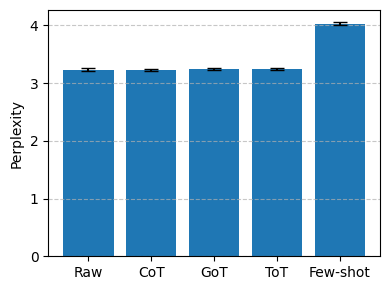

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('/home/honglinbao/chain_of_hints/diff.csv')
columns = ['raw_ppl', 'cot_ppl', 'got_ppl', 'tot_ppl', 'one_shot_ppl']
labels = ['Raw', 'CoT', 'GoT', 'ToT', 'Few-shot']
means = [df[col].mean() for col in columns]
stds = [df[col].std() for col in columns]
n = df[columns[0]].count() 
cis = 1.96 * np.array(stds) / np.sqrt(n)
plt.figure(figsize=(4, 3))
bars = plt.bar(labels, means, yerr=cis, capsize=5)
plt.ylabel("Perplexity")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [4]:
import pandas as pd
term = pd.read_csv('terms.csv')
term

,term,field
0,Gene editing,bio
1,Protein folding,bio
2,Mass spectrometry,bio
3,Cell signaling,bio
4,DNA methylation,bio
...,...,...
195,Mie scattering,phy
196,Rydberg blockade,phy
197,Fabry–Perot,phy
198,Raman spectroscopy,phy


In [1]:
import pandas as pd
import random
pairs_df = pd.read_csv('pairs_qwen.csv')  
term_df = pd.read_csv('terms.csv')  
pairs_df['term1'] = pairs_df['term1'].str.lower()
pairs_df['term2'] = pairs_df['term2'].str.lower()
term_df['term'] = term_df['term'].str.lower()
term_df['field'] = term_df['field'].str.lower()
term_to_field = term_df.set_index('term')['field'].to_dict()
field_to_terms = term_df.groupby('field')['term'].apply(set).to_dict()
def find_same_field_terms(row):
    term1 = row['term1']
    term2 = row['term2']
    field = term_to_field.get(term1)
    if field is None:
        return None
    terms = field_to_terms[field] - {term1, term2}
    if not terms:
        return None
    return random.choice(list(terms)) 
pairs_df['same_field_term1'] = pairs_df.apply(find_same_field_terms, axis=1)
pairs_df[['term1', 'term2', 'same_field_term1']].to_csv('same_diff.csv', index=False)

In [12]:
import os
import pandas as pd
from openai import OpenAI

# OpenRouter configuration
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="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",
)

# Load CSV
csv_path = "diff.csv"
text_column = "abstract2"
context_column = "abstract1"
output_column = "gen_abs"

df = pd.read_csv(csv_path)
df[text_column] = df[text_column].fillna("")
df[context_column] = df[context_column].fillna("")

# Merge the two paper abstracts
df["merged"] = "paper1:\n" + df[context_column] + "\n\n" + "paper2:\n" + df[text_column]

# Define the function for generating hypotheses
def extract_hypotheses(text):
    if not text.strip():
        return ""

    try:
        response = client.chat.completions.create(
            messages=[
                {
                    "role": "system",
                    "content": "You are an experienced scientist.",
                },
                {
                    "role": "user",
                    "content": (
                        f"You are reading two papers to initiate an interdisciplinary research project.\n\n"
                        f"{text}\n\n"
                        "Your task: Based on these two abstracts, write an original abstract for a publishable paper "
                        "that meaningfully integrates the core ideas from both sources.\n\n"
                        "Instructions:\n"
                        "1. The generated abstract should be **clear, feasible, novel, and well-reasoned**.\n"
                        "2. **Avoid vague** or purely directional statements.\n"
                        "3. Only return the plain abstract starting with \"Abstract:\". **Do not include any other commentary**.\n"
                        "4. **Be brief** and limit your response to approximately 200 words.\n\n"
                        "Example output:\n"
                        "Abstract: <your response here>\n\n"
                        "Now, give me your responses:\n"
                    ),
                },
            ],
            model="meta-llama/llama-3.1-8b-instruct"
        )
        output_text = response.choices[0].message.content.strip()
        return output_text

    except Exception as e:
        print(f"Error at row: {e}")
        return f"ERROR: {str(e)}"

# Process rows and save periodically
results = []
for idx, row in df.iterrows():
    text = row["merged"]
    result = extract_hypotheses(text)
    results.append(result)

    # Save checkpoint every 100 rows
    if (idx + 1) % 100 == 0:
        temp_df = df.loc[:idx, ["raw_id"]].copy()
        temp_df[output_column] = results
        temp_df.to_csv("raw.csv", index=False)
        print(f"Checkpoint saved at row {idx+1}")

# Final save
df[output_column] = results
final_df = df[["raw_id", output_column]]
final_df.to_csv("raw.csv", index=False)

,raw_id,gen_abs
0,3,Abstract: A novel approach to predicting asthm...
1,8,Abstract:\n\nManaging chronic medical conditio...
2,43,Abstract:\n\nPregnant women with asthma repres...
3,44,Abstract: \nTitle: Adaptive Scheduling and Eme...
4,45,Abstract:\n\nAsthma exacerbations during pregn...
5,48,Abstract:\n\nAsthma in Pregnancy: Electronic C...
6,100,Abstract:\nAsthma exacerbations during pregnan...
7,101,Abstract: \n\nAdvances in computing power are ...
8,103,Abstract: \nUrbanization and industrialization...
9,104,Abstract:\n\nAsthma is a chronic medical condi...


In [2]:
import pandas as pd
df=pd.read_csv('ppl.csv')
df['raw'] = df['raw'].str.strip().str.replace('\n', ' ').str.lower()
df['cot'] = df['cot'].str.strip().str.replace('\n', ' ').str.lower()
df.to_csv('ppl.csv',index=False)
df

,raw_id,raw,cot
0,3,combining insights from respiratory physiology...,asthma exacerbation during pregnancy poses sig...
1,8,this paper presents an integrated framework fo...,clinical management of asthma during pregnancy...
2,43,the interdisciplinary link between asthma trig...,asthma management during pregnancy poses signi...
3,44,asthma exacerbations during pregnancy pose a s...,the increasing prevalence of asthma during pre...
4,45,asthma is a chronic medical condition that com...,asthma exacerbation during pregnancy poses a s...
...,...,...,...
2995,14976,this interdisciplinary research project merges...,the increasing interest in distributed wireles...
2996,14979,we report a novel approach to harnessing ambie...,this study integrates the disciplines of envir...
2997,14985,this paper presents a novel interdisciplinary ...,the complexity of cellular biology hinges on t...
2998,14989,this study investigates the effects of surface...,surface finishing treatments are increasingly ...


In [4]:
import re
import time
from typing import List, Tuple

NUM_CANDIDATES = 3      
GEN_TEMPERATURE = 0.7   
SCORE_TEMPERATURE = 0.3 
RETRY = 2        

import os
import pandas as pd
from openai import OpenAI

# OpenRouter configuration
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="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",
)

# Load CSV
csv_path = "diff.csv"
text_column = "abstract2"
context_column = "abstract1"
output_column = "gen_abs"

df = pd.read_csv(csv_path)
df=df.head(1)
df[text_column] = df[text_column].fillna("")
df[context_column] = df[context_column].fillna("")

# Merge the two paper abstracts
df["merged"] = "paper1:\n" + df[context_column] + "\n\n" + "paper2:\n" + df[text_column]

def _gen_once(text: str) -> str:
    for attempt in range(RETRY + 1):
        try:
            resp = client.chat.completions.create(
                messages=[
                    {"role": "system", "content": "You are a creative, experienced scientist."},
                    {
                        "role": "user",
                        "content": (
                            f"You are reading two papers to initiate an interdisciplinary research project.\n\n"
                            f"{text}\n\n"
                            "Your task: Based on these two abstracts, write an original abstract for a publishable paper "
                            "that meaningfully integrates the core ideas from both sources.\n\n"
                            "Instructions:\n"
                            "1. The generated abstract should be **clear, feasible, novel, and well-reasoned**.\n"
                            "2. **Avoid vague** or purely directional statements.\n"
                            "3. Only return the plain abstract starting with \"Abstract:\". **Do not include any other commentary**.\n"
                            "4. **Be brief** and limit your response to approximately 200 words.\n\n"
                            "Example output:\n"
                            "Abstract: <your response here>\n\n"
                            "Now, give me your responses:\n"
                        ),
                    },
                ],
                model="meta-llama/llama-3.1-8b-instruct",
                temperature=GEN_TEMPERATURE,
            )
            return resp.choices[0].message.content.strip()
        except Exception as e:
            if attempt < RETRY:
                #time.sleep(0.8 * (attempt + 1))
                continue
            return f"ERROR_GEN: {e}"

def _score_candidate(plan_text: str, cand: str) -> int:
    score_prompt = (
        "Task: Evaluate the following candidate abstract for whether it closely follows the instructions "
        "(clarity, feasibility, specificity, novelty, possibility, and how well it integrates the two provided paper abstracts (the context)).\n\n"
        "Give a single integer score from 1 (poor) to 10 (excellent). Then one short reason on a new line.\n\n"
        f"Context (The Provided Paper Abstracts):\n{plan_text}\n\n"
        f"Candidate Abstract for Evaluation:\n{cand}\n\n"
        "Answer strictly as:\nScore: <integer 1-10>\nReason: <one short sentence>"
    )
    for attempt in range(RETRY + 1):
        try:
            resp = client.chat.completions.create(
                model="meta-llama/llama-3.1-70b-instruct",
                messages=[
                    {"role": "system", "content": "You are a critical scientific evaluator."},
                    {"role": "user", "content": score_prompt},
                ],
                temperature=SCORE_TEMPERATURE,
            )
            txt = resp.choices[0].message.content.strip()
            m = re.search(r"Score:\s*([1-9]|10)\b", txt)
            if m:
                return int(m.group(1))
            m2 = re.search(r"\b(10|[1-9])\b", txt)
            return int(m2.group(1)) if m2 else 0
        except Exception:
            if attempt < RETRY:
                #time.sleep(0.8 * (attempt + 1))
                continue
            return 0

def extract_hypotheses(text: str) -> str:
    if not text.strip():
        return ""

    candidates: List[str] = []
    for _ in range(NUM_CANDIDATES):
        cand = _gen_once(text)
        candidates.append(cand)

    if all(c.startswith("ERROR_GEN") for c in candidates):
        return candidates[0]

    scored: List[Tuple[int, str]] = []
    plan_text = f"Inputs (for Evaluation):\n\n{text}\n"
    for cand in candidates:
        score = _score_candidate(plan_text, cand)
        scored.append((score, cand))

    best_score, best_cand = max(scored, key=lambda x: x[0])
    return best_cand

# Process rows and save periodically
results = []
for idx, row in df.iterrows():
    text = row["merged"]
    result = extract_hypotheses(text)  
    results.append(result)

    # Save checkpoint every 100 rows
    if (idx + 1) % 100 == 0:
        temp_df = df.loc[:idx, ["raw_id"]].copy()
        temp_df[output_column] = results
        temp_df.to_csv("got.csv", index=False)
        print(f"Checkpoint saved at row {idx+1}")

# Final save
df[output_column] = results
final_df = df[["raw_id", output_column]]
final_df

,raw_id,gen_abs
0,3,Abstract: \n\nWe propose an innovative approac...


In [ ]:
#same field distance 0.128
#diff field distance 0.343

import numpy as np
import pandas as pd
import ast

# --- Step 1: Load main embedding DataFrame ---
df = pd.read_parquet('/net/scratch/honglinbao/coh_2015.parquet')
if isinstance(df['embedding'].iloc[0], str):
    df['embedding'] = df['embedding'].apply(ast.literal_eval)
df['embedding'] = df['embedding'].apply(np.array)

FileNotFoundError: [Errno 2] No such file or directory: '../diff.csv'

In [9]:
# --- Step 2: Load A-B pairs from CSV ---
pairs_df = pd.read_csv("diff.csv") 
pairs_df= pairs_df.sample(20)

# --- Step 3: Define capsule function ---
from math import hypot, isclose
def is_in_capsule(P, A, B, k=0.235, tol=1e-12):
    """
    Return True if point P is inside/on the rectangle:
      - Long axis along AB
      - Height = |AB|
      - Fixed half-width = 0.235 (total width = 0.47), independent of |AB|
    """
    ax, ay = A
    bx, by = B
    px, py = P

    # AB vector and length (height)
    vx, vy = bx - ax, by - ay
    h = hypot(vx, vy)
    if isclose(h, 0.0, abs_tol=tol):
        raise ValueError("A and B must be distinct to define the field.")

    # Orthonormal basis: v along AB, u perpendicular to AB
    vx, vy = vx / h, vy / h      # unit along AB
    ux, uy = -vy, vx             # unit perpendicular

    # Center of the field
    cx, cy = (ax + bx) / 2.0, (ay + by) / 2.0

    # Local coordinates of P in (u, v) frame
    rx, ry = px - cx, py - cy
    x_local = rx * ux + ry * uy   # perpendicular to AB (half-width check)
    y_local = rx * vx + ry * vy   # along AB (half-height check)

    half_height = h / 2.0
    half_width  = k  # fixed 0.235

    return (abs(x_local) <= half_width + tol) and (abs(y_local) <= half_height + tol)

# --- Step 4: Precompute all embeddings ---
id_to_vec = dict(zip(df['id'], df['embedding']))
points = np.vstack(df['embedding'].values)

# --- Step 5: Process each A-B pair ---
results = []
k = 0.235

for _, row in pairs_df.iterrows():
    ida = row['id1']
    idb = row['id2']
    
    if ida not in id_to_vec or idb not in id_to_vec:
        continue  # skip missing ids
    
    A = id_to_vec[ida]
    B = id_to_vec[idb]
    
    # Compute capsule membership
    in_capsule_mask = np.array([is_in_capsule(p, A, B, k) for p in points])
    capsule_df = df[in_capsule_mask].copy()
    capsule_df = capsule_df[~capsule_df['id'].isin([ida, idb])]
    
    # Sample
    sampled_df = capsule_df.sample(frac=0.01, random_state=42)
    sampled_ids = sampled_df['id'].tolist()
    total_in_capsule = len(capsule_df)

    # Append result
    results.append({
        'A': ida,
        'B': idb,
        'sampled_ids': sampled_ids,
        'total_count': total_in_capsule
    })

# --- Step 6: Save to new CSV ---
output_df = pd.DataFrame(results)
output_df

,A,B,sampled_ids,total_count
0,terms38,terms72,"[2869586259, 1760858340, 2914423112, 200540397...",582689
1,terms21,terms160,"[1991318456, 295962036, 2984002611, 2396434625...",427270
2,terms56,terms172,"[2020109309, 1670780127, 2295722352, 287070706...",343789
3,terms47,terms147,"[2565017630, 2341889350, 2297685068, 246462326...",807789
4,terms67,terms171,"[2829168162, 2233237926, 1812201962, 287571123...",480784
5,terms130,terms194,"[2417266958, 1972645860, 1951320418, 190934385...",639188
6,terms74,terms199,"[2292104730, 2339247965, 2171544217, 255351363...",809478
7,terms77,terms188,"[2923544005, 2823886976, 2576389478, 287788426...",504633
8,terms21,terms103,"[1550197442, 2126954467, 1811856992, 286164849...",769456
9,terms48,terms165,"[2261178738, 2175711684, 2212629603, 225897936...",364136


In [11]:
import pandas as pd
import random
results = []

for _, row in output_df.iterrows():
    A = row['A']
    B = row['B']
    sampled_ids = row['sampled_ids']

    for _ in range(10000):
        N = random.randint(1, 9)
        middle_nodes = random.sample(sampled_ids, N)
        path = [A] + [str(node) for node in middle_nodes] + [B]
        path_str = ", ".join(path)
        results.append({
            'A': A,
            'B': B,
            'Sequence': path_str,
            'Length': N+1
        })

final_df = pd.DataFrame(results)
final_df.to_csv('sample.csv',index=False)

In [8]:
import pandas as pd
import re

# Load data
df = pd.read_csv('run.csv')

# Define cleaning function
def clean_text(text):
    if pd.isna(text):
        return text
    # Remove everything before and including "Abstract:" (case-sensitive)
    idx = text.find("Abstract:")
    if idx != -1:
        text = text[idx + len("Abstract:"):]
    # Lowercase
    text = text.lower()
    # Remove \n
    text = text.replace('\n', ' ')
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply to all target columns
for col in ['raw', 'cot', 'one_shot', 'got', 'tot']:
    df[col] = df[col].apply(clean_text)
df.to_csv('run.csv',index=False)

In [3]:
import pandas as pd
df=pd.read_csv('diff.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   raw_id             3000 non-null   int64  
 1   id1                3000 non-null   object 
 2   id2                3000 non-null   object 
 3   FieldOfStudyName1  3000 non-null   object 
 4   FieldOfStudyName2  3000 non-null   object 
 5   similarity_ids     3000 non-null   float64
 6   FieldPair          3000 non-null   object 
 7   paper1             3000 non-null   int64  
 8   paper2             3000 non-null   int64  
 9   sim_id1_paper1     3000 non-null   float64
 10  sim_id2_paper2     3000 non-null   float64
 11  sim_paper1_paper2  3000 non-null   float64
 12  distance           3000 non-null   float64
 13  abstract1          3000 non-null   object 
 14  abstract2          3000 non-null   object 
 15  raw                3000 non-null   object 
 16  cot                2999 

In [3]:
import pandas as pd

# Load the data
df = pd.read_csv('diff.csv')
df2 = pd.read_csv('diff2.csv')

# Define the columns to merge (including 'raw_id' for alignment)
columns_to_merge = [
    'raw_id', 'raw', 'cot', 'one_shot', 'got', 'tot',
    'raw_ppl', 'cot_ppl', 'got_ppl', 'tot_ppl', 'one_shot_ppl'
]

# Merge df2 into df based on 'raw_id'
df_merged = df.merge(df2[columns_to_merge], on='raw_id', how='left')
df_merged.to_csv('diff.csv',index=False)

In [22]:
import pandas as pd
df = pd.read_csv('diff.csv')
df

,raw_id,id1,id2,FieldOfStudyName1,FieldOfStudyName2,similarity_ids,FieldPair,paper1,paper2,sim_id1_paper1,sim_id2_paper2,sim_paper1_paper2,distance,abstract1,abstract2,raw,cot,one_shot,got,tot
0,3,terms1,terms54,bio,comp,-0.999168,"('bio', 'comp')",1543300511,2870319626,1.0,1.0,-0.999168,0.244131,poster presentation background asthma is one o...,the invention discloses a motion feature extra...,asthma exacerbation during pregnancy poses sig...,"pregnancy exacerbates asthma, a chronic condit...",this study integrates machine learning techniq...,monitoring pregnant women with asthma requires...,pregnancy is a critical period for both mother...
1,8,terms1,terms59,bio,comp,-0.969334,"('bio', 'comp')",1543300511,2183625092,1.0,1.0,-0.969334,0.188680,poster presentation background asthma is one o...,large-scale applications expressed as scientic...,managing chronic medical conditions during pre...,managing chronic medical conditions like asthm...,"in the context of pregnancy, asthma exacerbati...",the management of asthma during pregnancy pose...,the management of asthma in pregnant individua...
2,43,terms1,terms94,bio,comp,-0.999168,"('bio', 'comp')",1543300511,2838193100,1.0,1.0,-0.999168,0.208087,poster presentation background asthma is one o...,the utility model discloses a novel accuse cig...,asthma is a chronic medical condition that com...,asthma management during pregnancy is a critic...,asthma exacerbation during pregnancy poses sig...,"in this study, we investigate the impact of ci...",this study integrates two seemingly disparate ...
3,44,terms1,terms95,bio,comp,-0.969586,"('bio', 'comp')",1543300511,2249686861,1.0,1.0,-0.969586,0.290000,poster presentation background asthma is one o...,uncoordinated charging of electric vehicles (e...,the integration of electric vehicles (evs) int...,asthma exacerbation during pregnancy poses sig...,asthma is a chronic condition that complicates...,the integration of electric vehicles (evs) int...,the integration of electric vehicles (evs) in ...
4,45,terms1,terms96,bio,comp,-0.987763,"('bio', 'comp')",1543300511,2247180262,1.0,1.0,-0.987763,0.206155,poster presentation background asthma is one o...,"in past years, ais are powerful and useful alg...",asthma exacerbations during pregnancy pose sig...,this study proposes a novel approach to improv...,"we propose an innovative, hybrid approach that...",asthma exacerbations during pregnancy can lead...,asthma exacerbations during pregnancy pose sig...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,14976,terms150,terms177,soc,phy,-0.999450,"('phy', 'soc')",2333203316,1539304985,1.0,1.0,-0.999450,0.441022,"carl smith. chicago, il: university of chicago...",this paper presents an overview of the design ...,this paper presents a novel approach to poweri...,this paper presents a novel approach to design...,we develop an intelligent wireless sensor netw...,this paper presents a novel approach to design...,this paper presents a novel approach to the de...
2996,14979,terms150,terms180,soc,phy,-0.984935,"('phy', 'soc')",2333203316,2078800225,1.0,1.0,-0.984935,0.350143,"carl smith. chicago, il: university of chicago...",there has been much recent interest in the res...,this paper presents a novel interdisciplinary ...,this paper presents a novel approach to optimi...,we propose a novel framework for designing and...,title: optimizing nonlinear energy harvesting ...,this paper explores the application of nonline...
2997,14985,terms150,terms186,soc,phy,-0.999151,"('phy', 'soc')",2333203316,2311694173,1.0,1.0,-0.999151,0.321403,"carl smith. chicago, il: university of chicago...","to understand the structure function paradigm,...",this study combines insights from humanities a...,"titled ""deciphering the language of life: inte...",this paper proposes a novel approach to unders...,this interdisciplinary research project integr...,the structural biology of proteins in eco-cult...
2998,14989,terms150,terms190,soc,ph

In [19]:
#df = df.iloc[[2692]] 
import os
import pandas as pd
from openai import OpenAI

# OpenRouter configuration
client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key="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",
)

# Load CSV
csv_path = "diff.csv"
text_column = "abstract2"
context_column = "abstract1"
output_column = "gen_abs"

df = pd.read_csv(csv_path)
df = df.iloc[[2692]] 
df[text_column] = df[text_column].fillna("")
df[context_column] = df[context_column].fillna("")

# Merge the two paper abstracts
df["merged"] = "paper1:\n" + df[context_column] + "\n\n" + "paper2:\n" + df[text_column]

# Define the function for generating hypotheses
def extract_hypotheses(text):
    if not text.strip():
        return ""

    try:
        response = client.chat.completions.create(
            messages=[
                {
                    "role": "system",
                    "content": "You are a creative, experienced scientist.",
                },
                {
                    "role": "user",
                    "content": (
                        f"You are reading two papers to initiate an interdisciplinary research project.\n\n"
                        f"{text}\n\n"
                        "Your task: Based on these two abstracts, write an original abstract for a publishable paper "
                        "that meaningfully integrates the core ideas from both sources.\n\n"
                        "Instructions:\n"
                        "1. The generated abstract should be **clear, feasible, novel, and well-reasoned**.\n"
                        "2. **Avoid vague** or purely directional statements.\n"
                        "3. Only return the plain abstract starting with \"Abstract:\". **Do not include any other commentary**.\n"
                        "4. **Be brief** and limit your response to approximately 200 words.\n\n"
                        "Example output:\n"
                        "Abstract: <your response here>\n\n"
                        "**Think step by step**, using intermediate concepts to ensure a smooth transition throughout your generated abstract.\n\n"
                        "Now, give me your responses:\n"
                    ),
                },
            ],
            model="meta-llama/llama-3.1-8b-instruct",
            temperature=0.7,
        )
        output_text = response.choices[0].message.content.strip()
        return output_text

    except Exception as e:
        print(f"Error at row: {e}")
        return f"ERROR: {str(e)}"

# Process rows and save periodically
results = []
for idx, row in df.iterrows():
    text = row["merged"]
    result = extract_hypotheses(text)
    results.append(result)

    # Save checkpoint every 100 rows
    if (idx + 1) % 100 == 0:
        temp_df = df.loc[:idx, ["raw_id"]].copy()
        temp_df[output_column] = results
        temp_df.to_csv("cot.csv", index=False)
        print(f"Checkpoint saved at row {idx+1}")

# Final save
df[output_column] = results
df

,raw_id,id1,id2,FieldOfStudyName1,FieldOfStudyName2,similarity_ids,FieldPair,paper1,paper2,sim_id1_paper1,...,distance,abstract1,abstract2,raw,cot,one_shot,got,tot,merged,gen_abs
2692,13482,terms120,terms183,soc,phy,-0.992423,"('phy', 'soc')",1488466620,2242396630,1.0,...,0.25,the purpose of this research was to investigat...,"in this paper, a wideband indoor body-to-body ...",this study investigates the potential of weara...,NaN,to ensure seamless communication among emergen...,this study integrates human-centered design pr...,this study integrates human-centered design pr...,paper1:\nthe purpose of this research was to i...,Abstract: This study integrates human-centered...


In [20]:
print(df['gen_abs'][2692])

Abstract: This study integrates human-centered design principles with cutting-edge wireless communication technologies to develop an innovative, wearable system for public safety applications. Building on previous work on perceived usability metrics, we designed a user-friendly interface for firefighters to seamlessly interact with their colleagues and access critical information during emergency operations. To enable high-speed data transfer, we utilized wideband indoor body-to-body communication channels, characterized by means of the rms delay spread and 50% correlation bandwidth. Our experiments, replicated in a real-life rescue scenario, demonstrated the feasibility of using cavity-backed substrate integrated waveguide textile antennas to establish four independent body-to-body links. By leveraging the long-term evolution (lte) and lte-device-to-device (lte-d2d) standards, our system enables multimedia broadcast and real-time communication of on-body sensor data. The usability of 

In [14]:
import pandas as pd
df = pd.read_csv('diff.csv')
unique_abstracts = pd.Series(pd.concat([df['abstract1'], df['abstract2']]))
sample_abstracts = unique_abstracts.sample(n=3000, random_state=42)
sample_raw = df['raw'].sample(n=3000, random_state=42)
result = pd.DataFrame({
    'probable': sample_abstracts.values,
    'improbable': sample_raw.values
})
result.to_csv('truth2.csv',index=False)

In [1]:
import pandas as pd
df=pd.read_csv('diff.csv')
df

,raw_id,id1,id2,FieldOfStudyName1,FieldOfStudyName2,similarity_ids,FieldPair,paper1,paper2,sim_id1_paper1,...,raw_ppl,cot_ppl,got_ppl,tot_ppl,one_shot_ppl,raw_mutual_info,cot_mutual_info,got_mutual_info,tot_mutual_info,one_shot_mutual_info
0,3,terms1,terms54,bio,comp,-0.999168,"('bio', 'comp')",1543300511,2870319626,1.0,...,3.113981,3.138741,3.982030,2.568366,4.850343,1.284880,0.913200,0.957908,1.587716,1.497213
1,43,terms1,terms94,bio,comp,-0.999168,"('bio', 'comp')",1543300511,2838193100,1.0,...,3.196846,3.053252,3.831367,4.676816,3.074638,1.154977,0.867942,0.989878,1.285124,1.333179
2,44,terms1,terms95,bio,comp,-0.969586,"('bio', 'comp')",1543300511,2249686861,1.0,...,2.944955,2.834762,2.743327,3.967553,3.847409,2.006466,1.345615,1.835309,1.727777,1.655232
3,100,terms1,terms151,bio,phy,-0.518978,"('bio', 'phy')",1543300511,1971883911,1.0,...,2.656661,3.014732,2.961056,2.664759,2.766710,1.204641,1.066303,0.797540,1.323778,0.925296
4,103,terms1,terms154,bio,phy,-0.696633,"('bio', 'phy')",1543300511,1956926223,1.0,...,2.956280,2.969597,3.787576,3.326834,4.020096,0.703695,0.933028,0.716123,1.274339,0.868533
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,14902,terms149,terms153,soc,phy,-0.994272,"('phy', 'soc')",1822350688,2113370651,1.0,...,3.391867,2.928909,3.874435,3.139311,4.869579,1.046445,1.144306,0.702922,0.849107,0.686563
1496,14914,terms149,terms165,soc,phy,-0.995291,"('phy', 'soc')",1822350688,2043421353,1.0,...,3.398101,3.093078,2.505278,3.437007,3.473590,1.026208,1.021638,0.644974,0.772734,0.647605
1497,14917,terms149,terms168,soc,phy,-0.997547,"('phy', 'soc')",1822350688,2526975013,1.0,...,2.600373,3.084829,3.382443,3.103197,5.030283,0.884369,0.781464,0.775777,1.233838,0.243544
1498,14932,terms149,terms183,soc,phy,-0.991715,"('phy', 'soc')",1822350688,2242396630,1.0,...,3.234213,2.305950,2.793302,2.665853,3.298136,0.881628,1.009519,0.906042,0.687404,0.747709


In [6]:
import pandas as pd
from scipy import stats
df = pd.read_csv('mutual_info_pairs.csv')
df=df[df['column'] =='one_shot']
# Group by 'i' and compute mean + 95% CI for mi_bits_per_token
results = []
confidence_level = 0.95

for i_value, group in df.groupby('i'):
    mean_val = group['mi_bits_per_token'].mean()
    n = len(group)
    std_err = stats.sem(group['mi_bits_per_token'], nan_policy='omit')
    h = std_err * stats.t.ppf((1 + confidence_level) / 2, n - 1)
    mean_plus_ci = mean_val + h
    results.append({'i': i_value, 'mean': mean_val, 'ci_lower': mean_val - h, 'ci_upper': mean_val + h, 'mean_plus_95ci': mean_plus_ci})

results_df = pd.DataFrame(results)
results_df

/tmp/ipykernel_3657762/1396158353.py:12: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  std_err = stats.sem(group['mi_bits_per_token'], nan_policy='omit')


,i,mean,ci_lower,ci_upper,mean_plus_95ci
0,0,1.325517,1.299827,1.351208,1.351208
1,1,1.476809,1.370127,1.583490,1.583490
2,2,1.445284,1.305737,1.584831,1.584831
3,3,1.175353,1.073141,1.277564,1.277564
4,4,1.535316,1.153732,1.916901,1.916901
5,5,1.414635,0.590179,2.239091,2.239091
6,6,3.548323,-0.073421,7.170067,7.170067
7,7,0.658769,0.181772,1.135766,1.135766
8,8,0.657625,-0.090610,1.405860,1.405860
9,9,-0.338122,NaN,NaN,NaN


In [4]:
import pandas as pd
df = pd.read_csv('mutual_info_pairs.csv')
# Step 1: For each (column, row_index) get the maximum i
max_i_per_row = (
    df.groupby(['column', 'row_index'], as_index=False)['i']
      .max()
)
avg_max_i_per_column = (
    max_i_per_row.groupby('column')['i']
    .quantile(0.95)
    .reset_index(name='i_95_quantile')
)
print(avg_max_i_per_column)

     column  i_95_quantile
0       cot            6.0
1       got            6.0
2  one_shot            4.0
3       raw            6.0
4       tot            6.0


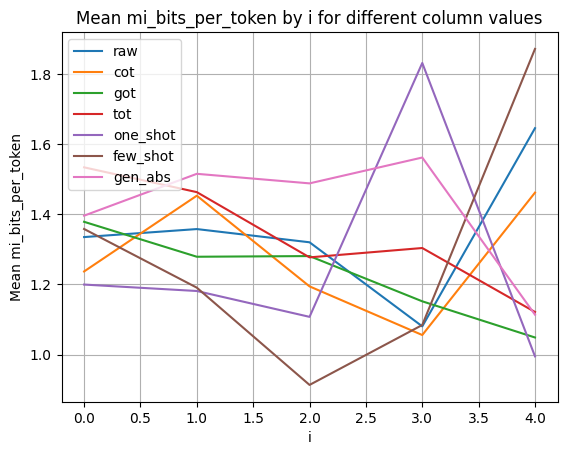

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('mutual_info_sample.csv')
df = df[df['i'] <5]
for col_value in df['column'].unique():
    sub_df = df[df['column'] == col_value]
    means_by_i = sub_df.groupby('i')['mi_bits_per_token'].mean()
    plt.plot(means_by_i.index, means_by_i.values, label=f'{col_value}')

plt.xlabel('i')
plt.ylabel('Mean mi_bits_per_token')
plt.title('Mean mi_bits_per_token by i for different column values')
plt.legend()
plt.grid(True)
plt.show()
plt.show()

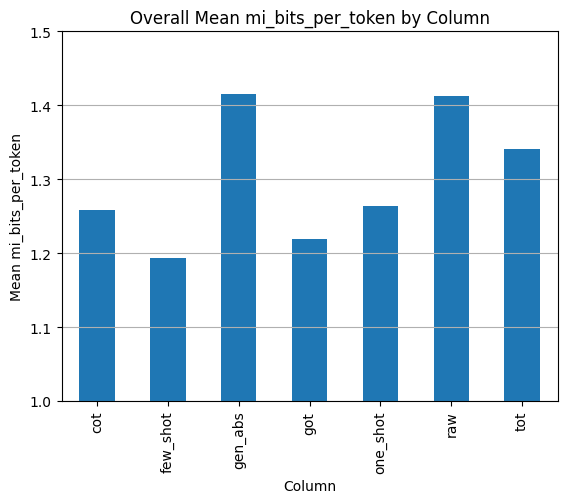

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('mutual_info_sample.csv')

# 按 column 分组计算整体平均值
means_by_col = df.groupby('column')['mi_bits_per_token'].mean()

# 画柱状图
means_by_col.plot(kind='bar')
plt.xlabel('Column')
plt.ylabel('Mean mi_bits_per_token')
plt.title('Overall Mean mi_bits_per_token by Column')
plt.grid(axis='y')
plt.ylim(1,1.5)
plt.show()
